# 📊 Classification automatique des activités (CRISP-DM) — V2

Améliorations :
- Chargement CSV robuste
- Détection dynamique des colonnes
- Labellisation améliorée
- Équilibrage des classes + class_weight
- Matrice de confusion + comparaison des modèles


## 1. 🎯 Business Understanding

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import resample

## 2. 📂 Data Understanding

In [8]:
import pandas as pd

df = pd.read_csv(
    "JobsDatasetProcessed (2).csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,ID,Query,Job Title,Description,IT Skills,Soft Skills,Education,Experience,Token Usage
0,3859,Artificial Intelligence,Collaborative Manipulation Roboticist,"Location: Schlumberger-Doll Research, Cambridg...","Collaborative Manipulation, Artificial Intelli...","Problem-solving, Organizational skills, Commun...",NaN,These skills are related to experience.,562
1,3764,Artificial Intelligence,Software Engineer - Innovation Lab,About DENSO DENSO is one of the largest global...,"Software Development, Infotainment Systems, Au...","Creativity, Collaboration, Problem-solving, Ad...",NaN,NaN,616
2,3597,Artificial Intelligence,"Director, Standards & Strategy","As a Director of Strategy & Strategy at Xperi,...","Audio/video codec, Media streaming and storage...","Participation in international standards, cons...","Skills Related to Education:, Undergraduate de...","Skills Related to Experience:, Audio/video cod...",549
3,3746,Artificial Intelligence,Business Strategy Consultant,If you have a strategic mindset and expertise ...,"Mobility technological trends expertise, Busin...","Strategic mindset, Thought leadership, Communi...",NaN,NaN,613
4,3872,Artificial Intelligence,Regular Full-Time,Mission Who We Are Founded and continuously le...,"Test planning, Bug tracking tools, Automation ...","Team player, Entrepreneurial mindset, Problem-...",NaN,NaN,1051


## 3. 🧹 Data Preparation

In [9]:
# Détection dynamique des colonnes
cols = df.columns
text_cols = [col for col in cols if df[col].dtype == 'object']

# Fusion de toutes les colonnes texte
df['combined_text'] = df[text_cols].fillna('').agg(' '.join, axis=1)

# Nettoyage
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['combined_text'].apply(clean_text)

# Labellisation améliorée
def categoriser(text):
    tech = ['python','java','sql','data','developer','engineering','machine learning']
    mg = ['manager','lead','project','scrum','director','strategy']
    soft = ['communication','teamwork','leadership','adaptability','problem solving']

    if any(w in text for w in tech):
        return 'technique'
    elif any(w in text for w in mg):
        return 'managerial'
    else:
        return 'soft_skills'

df['category'] = df['clean_text'].apply(categoriser)

print(df['category'].value_counts())

category
technique     215
managerial     11
Name: count, dtype: int64


## 4. ⚖️ Équilibrage des classes

In [10]:
# Équilibrage
df_max = df['category'].value_counts().max()
dfs = []

for cat in df['category'].unique():
    df_cat = df[df['category'] == cat]
    df_cat_up = resample(df_cat, replace=True, n_samples=df_max, random_state=42)
    dfs.append(df_cat_up)

df_balanced = pd.concat(dfs)
df_balanced = df_balanced.sample(frac=1, random_state=42)

print(df_balanced['category'].value_counts())

category
managerial    215
technique     215
Name: count, dtype: int64


## 5. 🤖 Modeling

In [11]:
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X = vectorizer.fit_transform(df_balanced['clean_text'])

encoder = LabelEncoder()
y = encoder.fit_transform(df_balanced['category'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'SVM': SVC(class_weight='balanced')
}

## 6. 📈 Evaluation


SVM
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        43

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86


Best Model: SVM


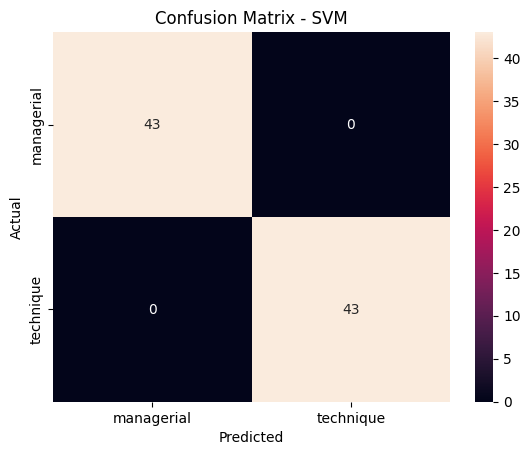

In [12]:
results = {}

# Puisqu'il n'y a qu'un seul modèle, nous pouvons l'évaluer directement
name = list(models.keys())[0]
model = models[name]

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
results[name] = acc

print(f"\n{name}")
print("Accuracy:", acc)
print(classification_report(y_test, y_pred, zero_division=0))

print("\nBest Model:", name)

# Matrice de confusion
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f"Confusion Matrix - {name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
print('Models used in this notebook:')
for name in models.keys():
    print(f'- {name}')

Models used in this notebook:
- SVM


## 7. 🚀 Deployment

In [14]:
def predict_activity(text, model_name):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    pred = models[model_name].predict(vec)
    return encoder.inverse_transform(pred)[0]

print(predict_activity('manage project team and communication', "SVM"))

technique
